In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms as T
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
from torchvision.io import read_image, decode_image
import torchvision.models as models

from torchinfo import summary

print("PyTorch ver:", torch.__version__)

PyTorch ver: 2.4.1


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [ ]:
from datasets import __version__ as datasets_version, DATASET_0, DATASET_2, get_image_title
from utils import __version__ as utils_version, display_rgb_distributions, UnNormalize

print("datasets ver:", utils_version)
print("utils ver:", datasets_version)

datasets ver: 1.3.0
utils ver: 1.0.4


In [4]:
DataPath = DATASET_2["path"]
ImageFile = "n04037443_racer.JPEG" #"n02128757_snow_leopard.JPEG"

In [5]:
def display_image(img_tensor, verbose=True):
    """
    Display a image contained in a tensor, assuming dimensions (C, H, W),
    using PIL.
    Dedicated to notebook env.
    """
    if verbose:
        print("Dimensions", img_tensor.size(), "\nValeur min:", img_tensor.min().item(), "\nValeur max:", img_tensor.max().item())

    img1 = T.functional.to_pil_image(img_tensor)
    display(img1)

In [6]:
imagenet_mean = DATASET_0["means"]
imagenet_std = DATASET_0["stds"]

transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [ ]:
filename = os.path.join(DataPath, ImageFile)
#img_tensor = read_image(filename) # Format : torch.Tensor
img_tensor = decode_image(filename) # Format : torch.Tensor

print(get_image_title(filename.split("/")[-1], DataPath))
display_image(img_tensor)

input = transforms(img_tensor)
display_image(input)

RuntimeError: image::decode_image() Expected a value of type 'Tensor' for argument 'data' but instead found type 'str'.
Position: 0
Value: '/Users/me/Documents/Work/Dev/_data/imagenet-sample-images-master/n04037443_racer.JPEG'
Declaration: image::decode_image(Tensor data, int mode, bool apply_exif_orientation=False) -> Tensor
Cast error details: Unable to cast /Users/me/Documents/Work/Dev/_data/imagenet-sample-images-master/n04037443_racer.JPEG to Tensor

In [8]:
batch_input = input.unsqueeze(dim=0)
batch_input.size()

torch.Size([1, 3, 224, 224])

Chargement du modèle AlexNet avec les poids obtenus avec l'entrainement sur [`IMAGENET1K`](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K), et affichage de sa composition :

In [9]:
model = models.alexnet(weights='IMAGENET1K_V1')
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Affichage des dimensions des sorties respectives des couches et des nombres de paramètres

In [10]:
#summary(model, input_size=torch.Size([1, 3, 224, 224]))
summary(model, input_size=batch_input.size(), mode="eval")

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 1000]                 --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 64, 55, 55]           23,296
│    └─ReLU: 2-2                         [1, 64, 55, 55]           --
│    └─MaxPool2d: 2-3                    [1, 64, 27, 27]           --
│    └─Conv2d: 2-4                       [1, 192, 27, 27]          307,392
│    └─ReLU: 2-5                         [1, 192, 27, 27]          --
│    └─MaxPool2d: 2-6                    [1, 192, 13, 13]          --
│    └─Conv2d: 2-7                       [1, 384, 13, 13]          663,936
│    └─ReLU: 2-8                         [1, 384, 13, 13]          --
│    └─Conv2d: 2-9                       [1, 256, 13, 13]          884,992
│    └─ReLU: 2-10                        [1, 256, 13, 13]          --
│    └─Conv2d: 2-11                      [1, 256, 13, 13]         

Affichage des différentes couches accessibles dans le modèle :

In [11]:
for i, layer in enumerate(model.features):
    print(f"[{i}]\t", layer)

[0]	 Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
[1]	 ReLU(inplace=True)
[2]	 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
[3]	 Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
[4]	 ReLU(inplace=True)
[5]	 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
[6]	 Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[7]	 ReLU(inplace=True)
[8]	 Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[9]	 ReLU(inplace=True)
[10]	 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
[11]	 ReLU(inplace=True)
[12]	 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)


Réalisation manuelle d'une passe d'inférence dans la partie convolutive, à recoller avec les infos obtenues avec `summary`.

In [12]:
output = batch_input
print("IN (size) : ", output.size())
for layer in model.features:
    print("after", layer)
    output = layer(output)
    print("\t", "OUT (size) : ", output.size())

IN (size) :  torch.Size([1, 3, 224, 224])
after Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
	 OUT (size) :  torch.Size([1, 64, 55, 55])
after ReLU(inplace=True)
	 OUT (size) :  torch.Size([1, 64, 55, 55])
after MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 OUT (size) :  torch.Size([1, 64, 27, 27])
after Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
	 OUT (size) :  torch.Size([1, 192, 27, 27])
after ReLU(inplace=True)
	 OUT (size) :  torch.Size([1, 192, 27, 27])
after MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
	 OUT (size) :  torch.Size([1, 192, 13, 13])
after Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 OUT (size) :  torch.Size([1, 384, 13, 13])
after ReLU(inplace=True)
	 OUT (size) :  torch.Size([1, 384, 13, 13])
after Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
	 OUT (size) :  torch.Size([1, 256, 13, 13])
after ReLU(inplace=True)


In [13]:
def i_suffix(i, he=True):
    f = "er" if he else "ère"
    return f if i==1 else "ème"

def display_pictures_grid(
        pictures: torch.Tensor,
        per_rows: int,
        titles: List[str]=None,
        suptitle: str="",
        figsize: Tuple[int, int]=(12, 12)
        ) -> None:
    """ 
    Display a grid of pictures
    
    - Arg(s):
        pictures: torch.Tensor
            Shape (n, C, H, W)
        per_rows: int
        titles: List[str]
            Shape (n) or None
        suptitle: str
        figsize: Tuple[int, int]
    """
    fig = plt.figure(figsize=figsize, layout='constrained')
    plt.rcParams['axes.titley'] = 1.0
    plt.rcParams['axes.titlepad'] = 1.2
    rows = pictures.size(0) // per_rows + 1
    for r in range(rows):
        for c in range(per_rows):
            i = r * per_rows + c
            if i < len(pictures):
                ax = fig.add_subplot(rows, per_rows, i+1, xticks = [], yticks = [])
                if titles:
                    ax.set_title(titles[i])
                if pictures[i].size(0) == 1:
                    ax.imshow(pictures[i].numpy().transpose(1, 2, 0), cmap='gray')
                else:
                    ax.imshow(pictures[i].numpy().transpose(1, 2, 0))
    if suptitle:
        plt.suptitle(suptitle)
    #plt.tight_layout()
    #plt.subplots_adjust(hspace=1)
    plt.show()

Affichage des différentes cartes d'activation obtenues après la première convolution, sans application d'une ReLU.

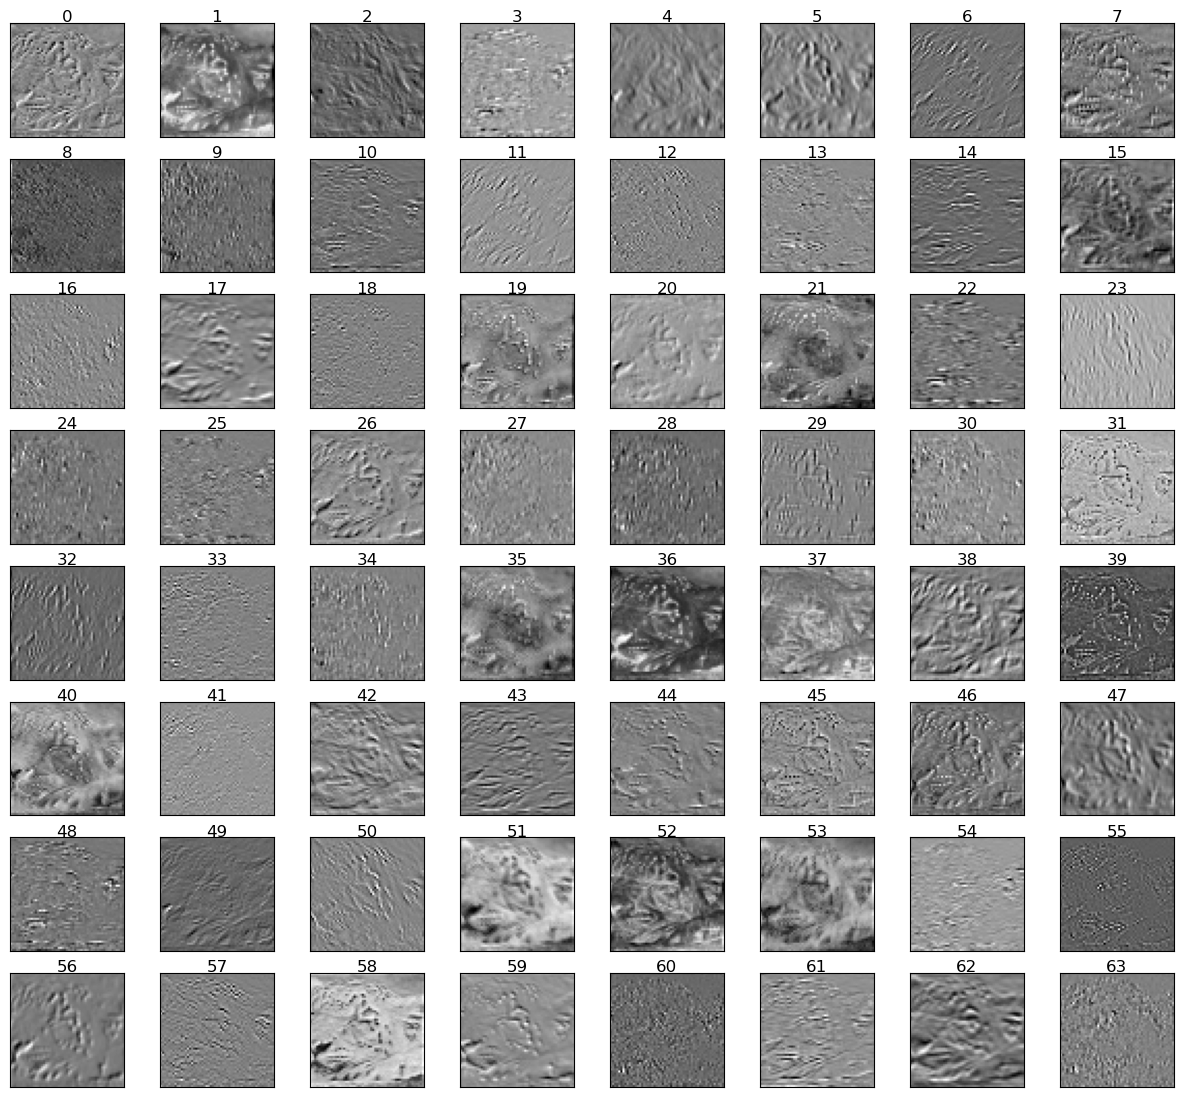

In [14]:
output = model.features[0](batch_input).detach()
display_pictures_grid(
    output.reshape((output.size(1), output.size(0), output.size(2), output.size(3))),
    per_rows=8,
    titles=range(output.size(1))
    )

Avec application d'un ReLU.

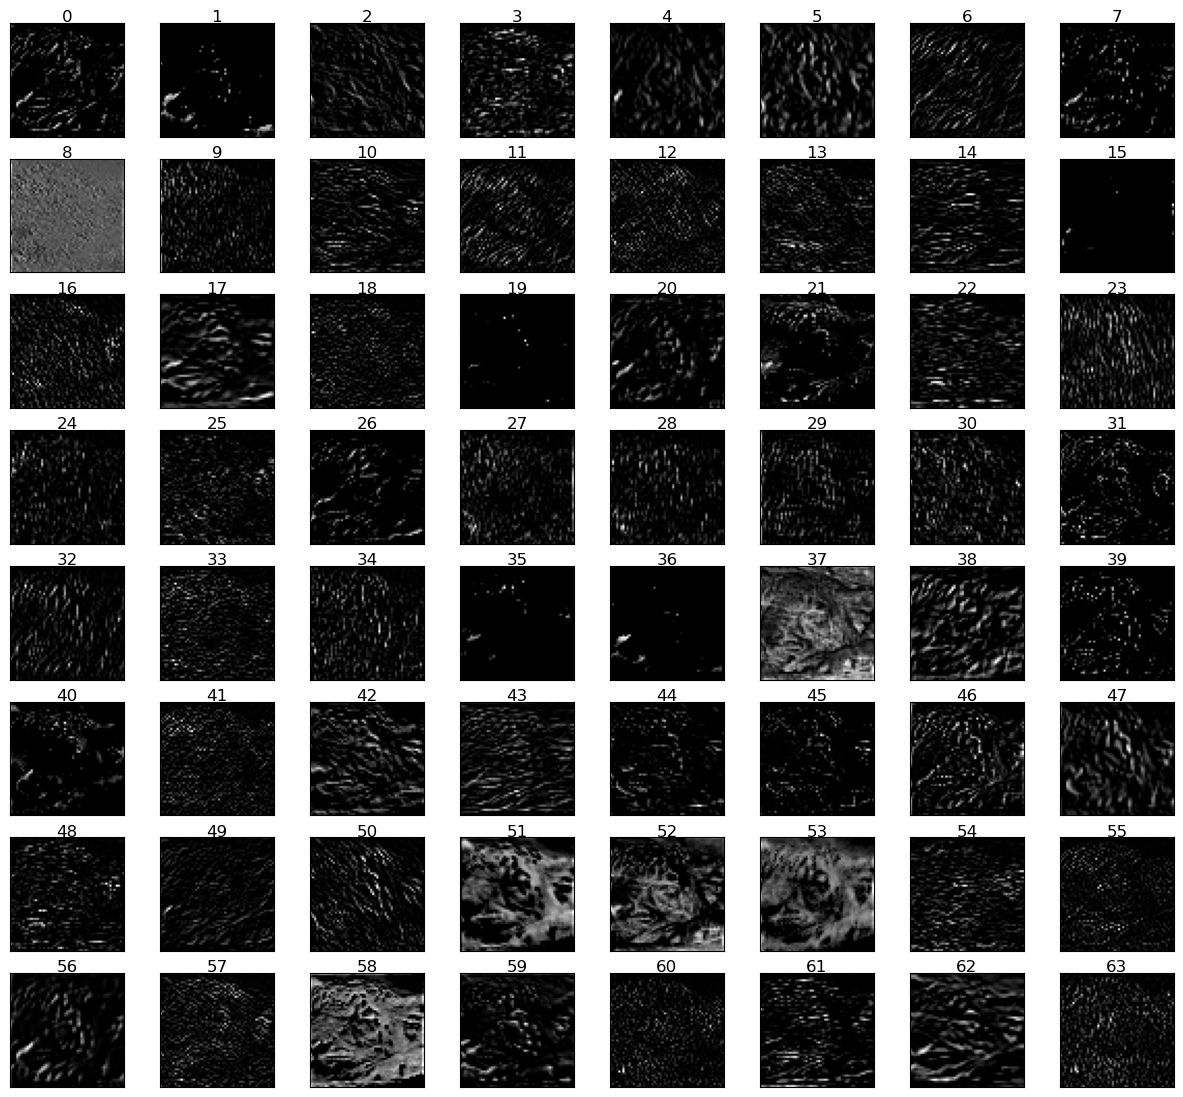

In [15]:
output_relu = model.features[1](model.features[0](batch_input)).detach()
display_pictures_grid(
    output_relu.reshape((output_relu.size(1), output_relu.size(0), output_relu.size(2), output_relu.size(3))),
    per_rows=8,
    titles=range(output_relu.size(1))
    )

Application d'une convolution transposée, afin de projeter les cartes de caractéristiques dans l'espace des pixels.

**Question** : comment manipuler les poids de la convolution apprise ?
Pour la première couche, nous avons:
$$(B, C_{in}, H_{in}, W_{in}) \times (C_{out}, C_{in}, K_h, K_w) \rightarrow (B, C_{out}, H_{out}, W_{out})$$

In [16]:
weights = model.features[0].weight
layer =  model.features[0]
flipped_weights = torch.flip(weights, [2, 3])

In [17]:
print("output", output_relu.size())
print("weights", weights.size())
print("flipped weights", flipped_weights.size())

output torch.Size([1, 64, 55, 55])
weights torch.Size([64, 3, 11, 11])
flipped weights torch.Size([64, 3, 11, 11])


Ici, la première couche de convolution du modèle contient $64 \times 3$ noyaux ($64$ groupes de $3$ noyaux) de dimension $(3, 3)$.

Affichage de la "déconvolution" avec les poids **non** renversés.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: -36.531776428222656 
Valeur max: 25.518489837646484


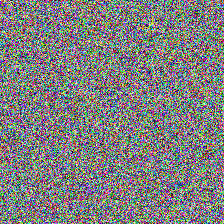

In [18]:
b_output = torch.nn.functional.conv_transpose2d(
    output_relu,
    weights,
    stride=layer.stride,
    padding=layer.padding,
    output_padding=1,
    dilation=layer.dilation
    )
in_pixel_space = b_output.detach().squeeze()
display_image(in_pixel_space)

Dénormalisation puis rétablissement de la distribution dans $[0, 1]$.

In [19]:
unnormalizer = UnNormalize(imagenet_mean, imagenet_std)

Dimensions torch.Size([3, 224, 224]) 
Valeur min: -7.727118015289307 
Valeur max: 6.328734397888184


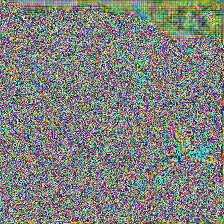

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 1.0


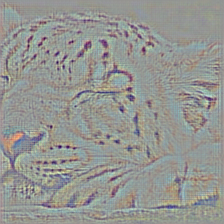

In [20]:
input_un = unnormalizer(in_pixel_space)
display_image(input_un)

b_output_un = input_un
b_output_un = b_output_un - b_output_un.min()
b_output_un = b_output_un / b_output_un.max()
display_image(b_output_un)

Application juste d'un ReLU pour être dans [0; N] puis rétablissement de la distribution dans $[0; 1]$.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 25.518489837646484


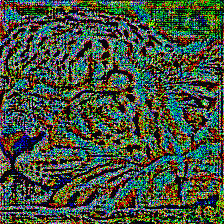

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 1.0


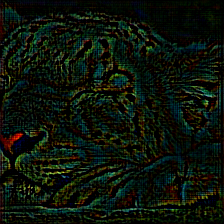

In [21]:
in_pixel_space_relu = torch.nn.functional.relu(in_pixel_space)
display_image(in_pixel_space_relu)

b_output_un = in_pixel_space_relu
b_output_un = b_output_un - b_output_un.min()
b_output_un = b_output_un / b_output_un.max()
display_image(b_output_un)

Affichage de la "déconvolution" avec les poids **renversés**.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 18.08832550048828


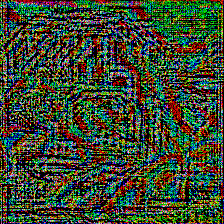

In [22]:
b_output_wf = torch.nn.functional.conv_transpose2d(
    output_relu,
    flipped_weights,
    stride=layer.stride,
    padding=layer.padding,
    output_padding=1,
    dilation=layer.dilation
    )
in_pixel_space_wf = torch.nn.functional.relu(b_output_wf.detach().squeeze())
display_image(in_pixel_space_wf)

Dénormalisation puis rétablissement de la distribution dans $[0; 1]$.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.4059999883174896 
Valeur max: 4.627226829528809


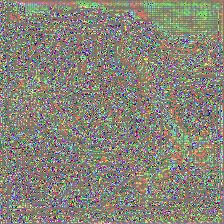

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 1.0


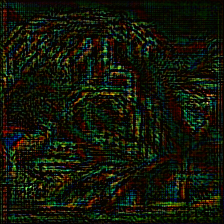

In [23]:
input_un = unnormalizer(in_pixel_space_wf)
display_image(input_un)

b_output_un = input_un
b_output_un = b_output_un - b_output_un.min()
b_output_un = b_output_un / b_output_un.max()
display_image(b_output_un)

Application juste d'un ReLU pour être dans [0; N] puis rétablissement de la distribution dans $[0; 1]$.

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 18.08832550048828


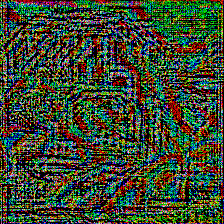

Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 1.0


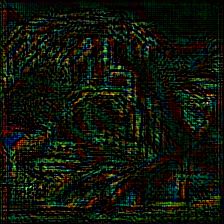

In [24]:
in_pixel_space_wf_relu = torch.nn.functional.relu(in_pixel_space_wf)
display_image(in_pixel_space_wf_relu)

b_output_un = in_pixel_space_wf_relu
b_output_un = b_output_un - b_output_un.min()
b_output_un = b_output_un / b_output_un.max()
display_image(b_output_un)